### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [6]:
for i in ['Marital_Status', 'Education', 'Dt_Customer']:
  display(df[i].value_counts())

,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


,count
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54


,count
Dt_Customer,
31-08-2012,12
12-05-2014,11
14-02-2013,11
12-09-2012,11
22-05-2014,10
...,...
01-11-2013,1
10-08-2013,1
11-10-2012,1


**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [7]:
# заповнюю як -1 аби при інтерпретації ці значення суттєво відрізнялись від решти
# після перших експериментів можна спробувати змінити
# окремо зберігаю в колонку місця, де заповнила дані

df['Income_not_filled'] = df.Income.isna()
df.Income = df.Income.fillna(-1)

Оскільки для задачі кластеризації найголовніше - не порушити базову структуру та розташування точок у просторі, можна використати метод імпутації, який і є заснованим на відстанях між точками - тоді буде збережена початкова "картина" та зникне ризик, що кластеризатор визначить окремі кластери навколо точок з імпутацією.



```
from sklearn.impute import KNNImputer

imputer = KNNImputer(
    n_neighbors=5,
    weights='uniform',
    metric='nan_euclidean',
    add_indicator=False
)

df[['Income']] = imputer.fit_transform(df[['Income']])
```



**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [10]:
df.Dt_Customer = pd.to_datetime(df.Dt_Customer, format='%d-%m-%Y')
df['Days_Since_Registration'] = (df.Dt_Customer.max() - df.Dt_Customer).dt.days

In [13]:
df['Years_Customer'] = df.Year_Birth.apply(lambda x: df.Dt_Customer.max().year - x)

In [14]:
df_education = pd.get_dummies(df.Education, prefix='education').astype(int)
df = pd.concat([df, df_education], axis=1)

In [15]:
df.Marital_Status.value_counts()

,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


In [16]:
marital_status_map ={'Alone': 'Single', 'Absurd':' Else', 'YOLO': 'Else'}
df['Marital_Status_clean'] = df.Marital_Status.map(marital_status_map)

In [17]:
df_ms = pd.get_dummies(df.Marital_Status_clean, prefix='marital').astype(int)
df = pd.concat([df, df_ms], axis=1)

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [18]:
X = df.drop(['ID', 'Dt_Customer', 'Education', 'Marital_Status', 'Marital_Status_clean'], axis=1)

In [19]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X)

labels = kmeans.predict(X)
print(labels)

[0 0 2 ... 0 2 0]


In [20]:
from sklearn.metrics import silhouette_score

centroids = kmeans.cluster_centers_
s = silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.53


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [21]:
import plotly.express as px

In [22]:
fig = px.scatter_3d(X,
    x='Income',
    y='MntFruits',
    z='NumDealsPurchases',
    color=labels,
    opacity=0.8,
    title='3D Scatter Plot Income x MntFruits x NumDealsPurchases',
)

fig.show()

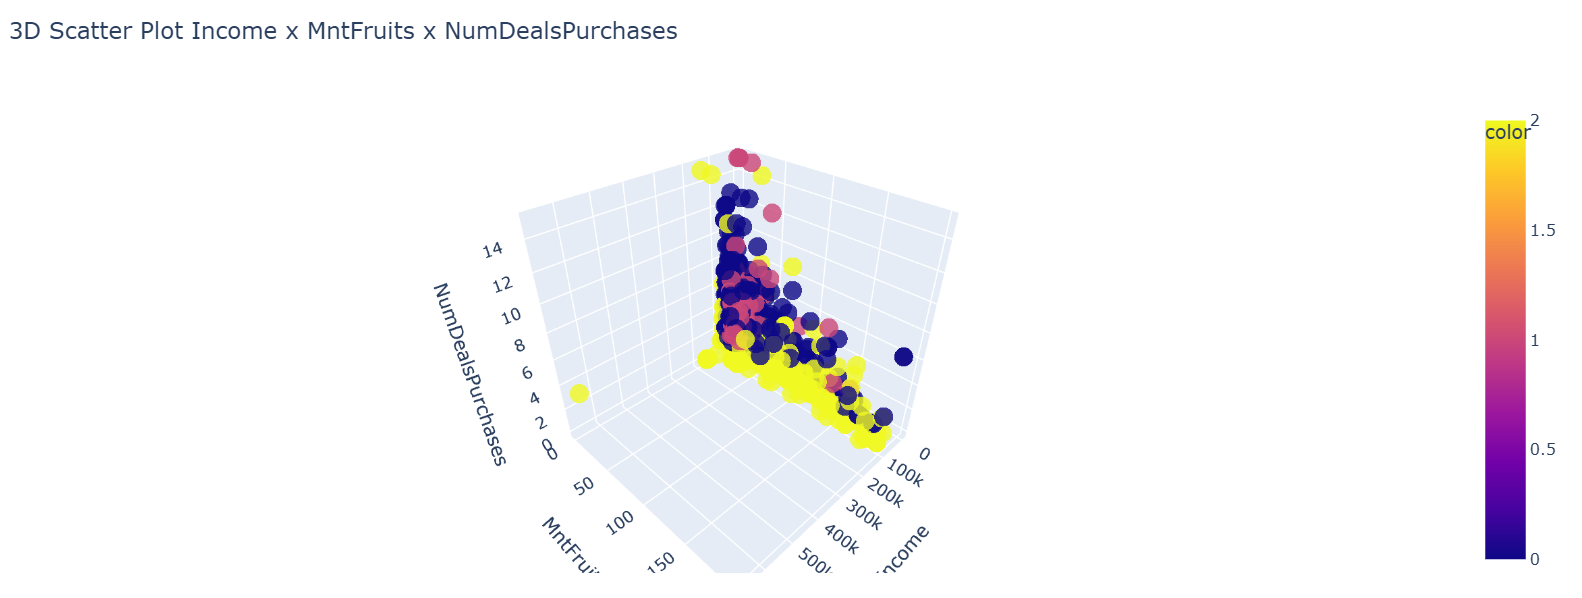

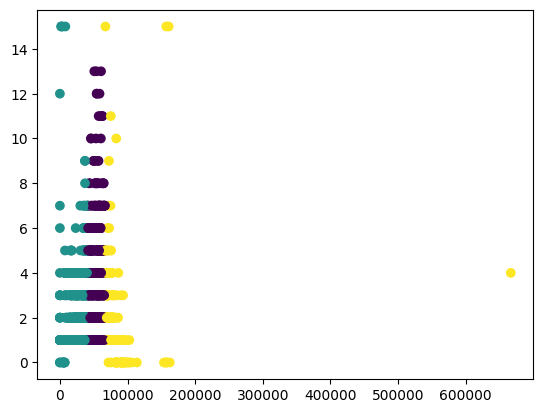

In [23]:
import matplotlib.pyplot as plt
plt.scatter(X['Income'], X['NumDealsPurchases'], c=labels)
plt.show()

In [24]:
fig = px.scatter_3d(X,
    x='Recency',
    y='Income',
    z='NumStorePurchases',
    color=labels,
    opacity=0.8,
    title='3D Scatter Plot Income x Recency x NumStorePurchases',
)

fig.show()

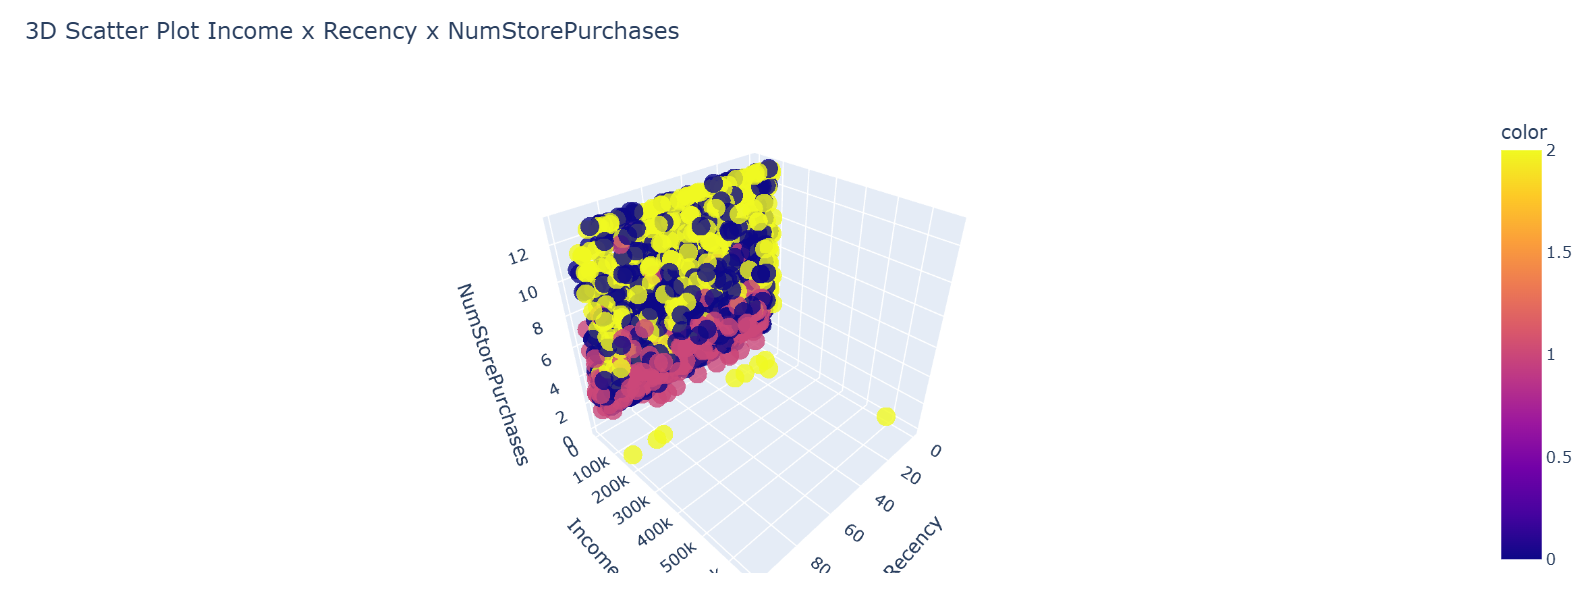

In [25]:
fig = px.scatter_3d(X,
    x='Kidhome',
    y='MntWines',
    z='NumDealsPurchases',
    color=labels,
    opacity=0.8,
    title='3D Scatter Plot Kidhome x MntWines x NumDealsPurchases',
)

fig.show()

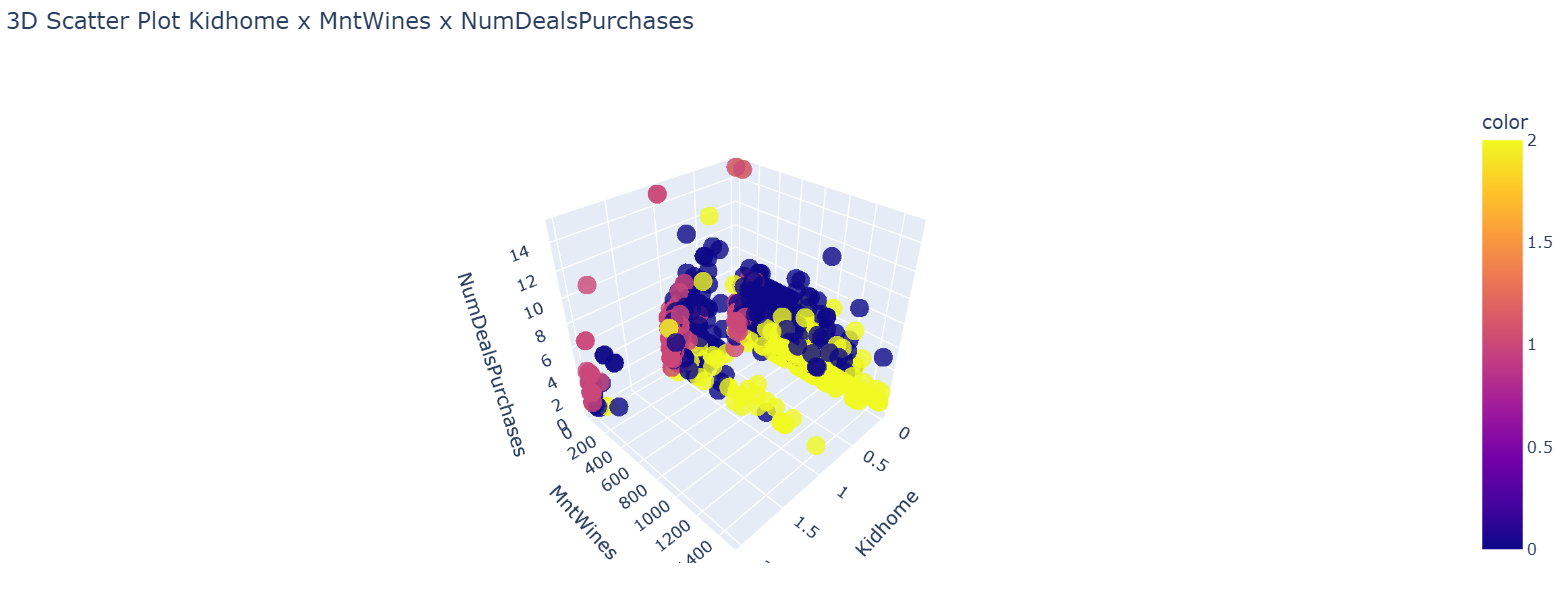

Поки що на мій погляд класттери не дуже маються сенс. Є також викиди по деяким колонкам (наприклад Income), які деж впливають на якість кластеризації. Також метрика силуету вже показала не надто гарний результат.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [26]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [27]:
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X_scaled_df)

labels = kmeans.predict(X_scaled_df)
print(labels)

[0 2 1 ... 0 1 1]


In [28]:
centroids = kmeans.cluster_centers_
s = silhouette_score(X_scaled_df, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.12


In [29]:
fig = px.scatter_3d(X_scaled_df,
    x='Income',
    y='MntFruits',
    z='NumDealsPurchases',
    color=labels,
    opacity=0.8,
    title='3D Scatter Plot Income x MntFruits x NumDealsPurchases',
)

fig.show()

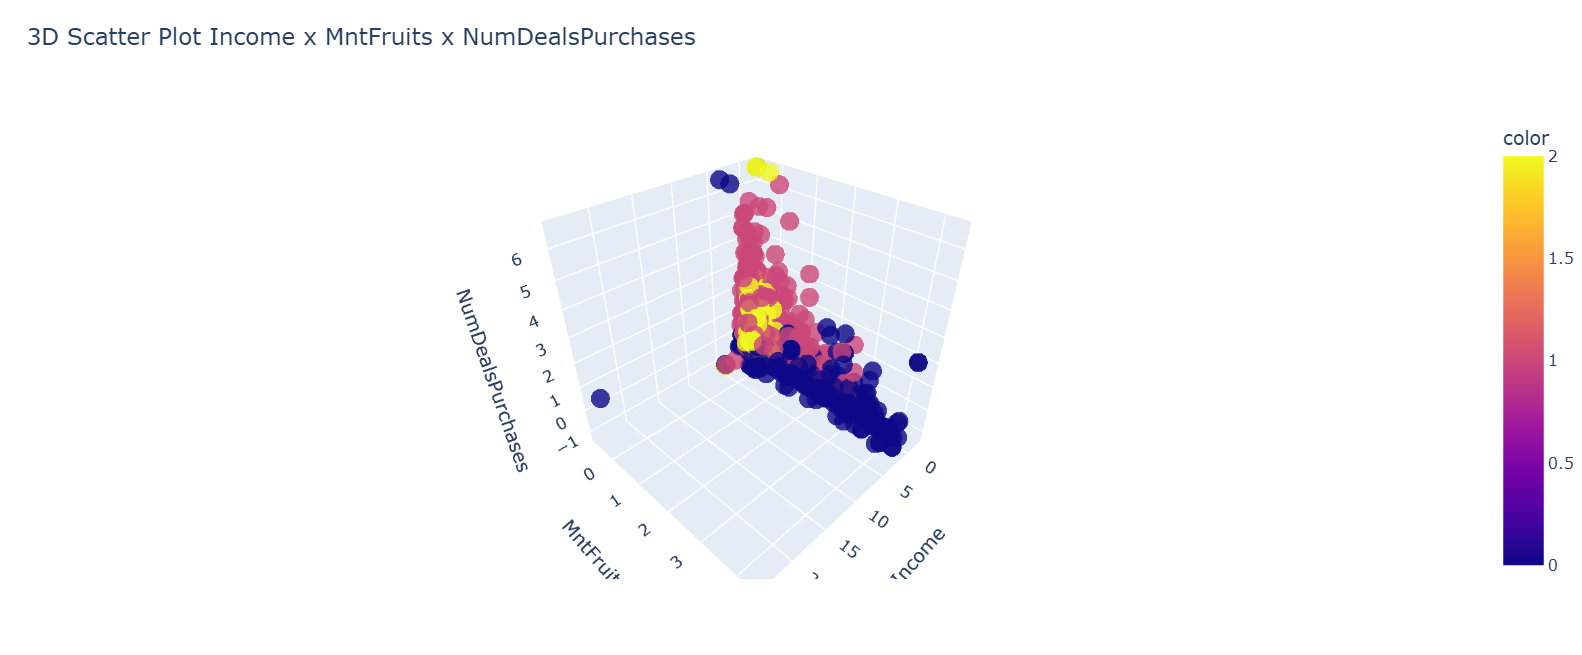

Метрика силуету погіршилась і на візуалізації все ще не видно логічного розділення

In [30]:
result_scaled = X_scaled_df.copy()

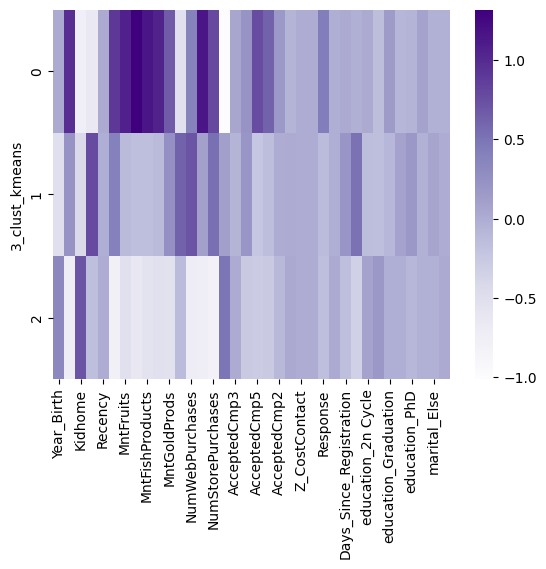

In [32]:
import seaborn as sns

result_scaled['3_clust_kmeans'] = labels
sns.heatmap(result_scaled.groupby(['3_clust_kmeans']).mean(), cmap="Purples");

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [33]:
from sklearn.preprocessing import RobustScaler

X_rob_scaled = RobustScaler().fit_transform(X)

X_rob_scaled_df = pd.DataFrame(X_rob_scaled, columns=X.columns)

In [34]:
X_clipped = X.copy()
num_cols = X_clipped.select_dtypes(include=[np.number]).columns

for col in num_cols:
  lo = X_clipped[col].quantile(0.01)
  hi = X_clipped[col].quantile(0.99)

  X_clipped[col] = X_clipped[col].clip(lower=lo, upper=hi)

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

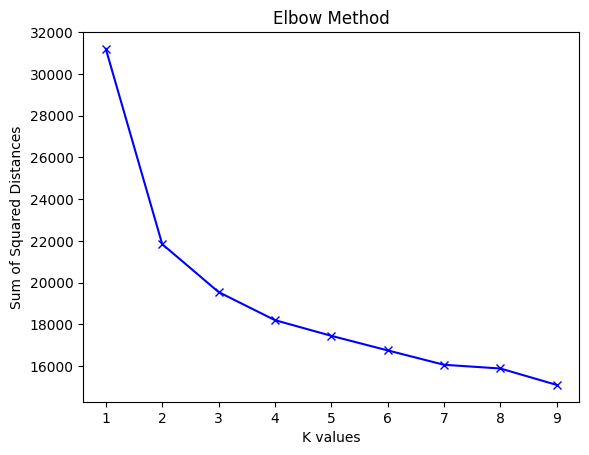

In [35]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X_rob_scaled_df)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [36]:
kmeans = KMeans(n_clusters=4, n_init='auto')
kmeans.fit(X_rob_scaled_df)

labels = kmeans.predict(X_rob_scaled_df)

In [37]:
centroids = kmeans.cluster_centers_
s = silhouette_score(X_rob_scaled_df, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.19


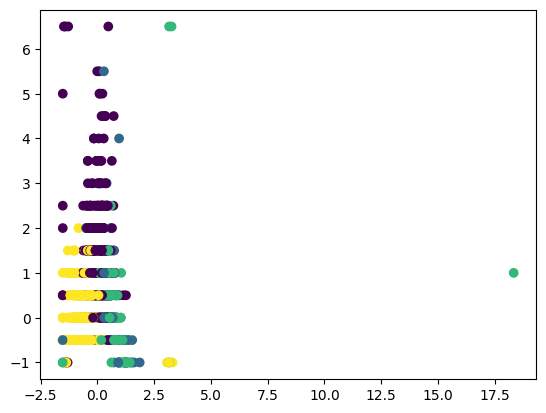

In [38]:
plt.scatter(X_rob_scaled_df['Income'], X_rob_scaled_df['NumDealsPurchases'], c=labels)
plt.show()

Метрика та графік не значно покращились на відмасштабованих даних з пригніченими викидами та з оптимальною кількістю кластерів

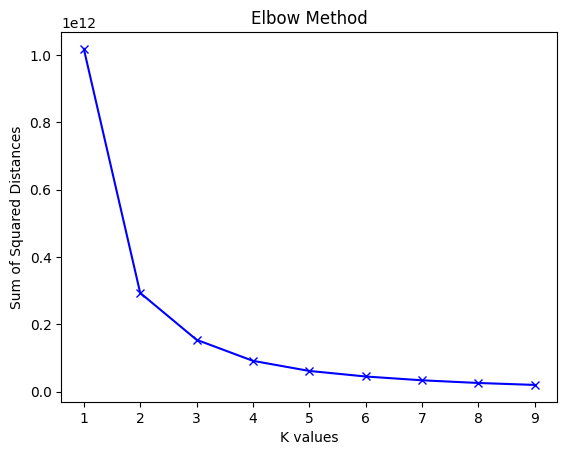

In [39]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X_clipped)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [40]:
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X_clipped)

labels = kmeans.predict(X_clipped)

centroids = kmeans.cluster_centers_
s = silhouette_score(X_clipped, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.54


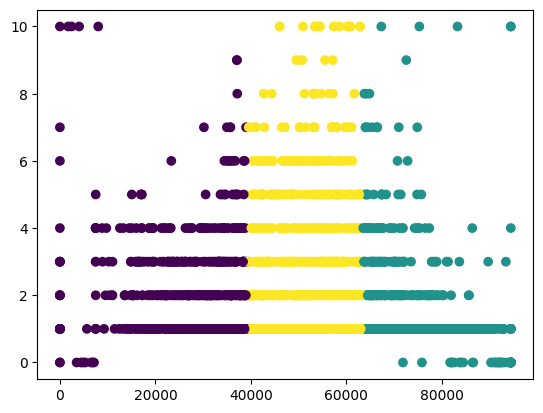

In [41]:
plt.scatter(X_clipped['Income'], X_clipped['NumDealsPurchases'], c=labels)
plt.show()

Метрика та графік вже значно кращі на невідмасштабованих даних з обрізаними викидами та з оптимальною кількістю кластерів

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

In [42]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

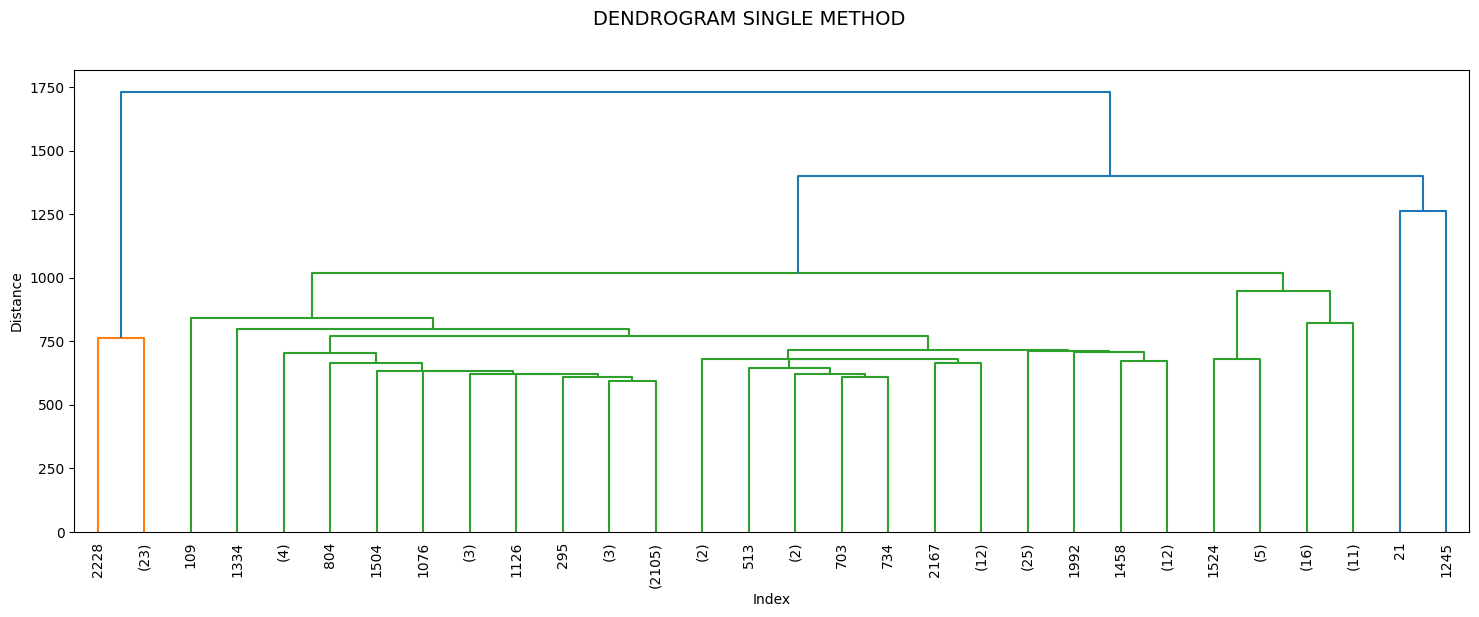

In [43]:
dist_sin = linkage(X_clipped, method='single')

plt.figure(figsize=(18,6))
dendrogram(dist_sin, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle('DENDROGRAM SINGLE METHOD', fontsize=14)
plt.show()

За дендрограмою помітно, що невелику перевагу має розділення на 2 кластери

In [44]:
X_clipped['2_clust'] = fcluster(dist_sin, 2, criterion='maxclust')
X_clipped['3_clust'] = fcluster(dist_sin, 3, criterion='maxclust')

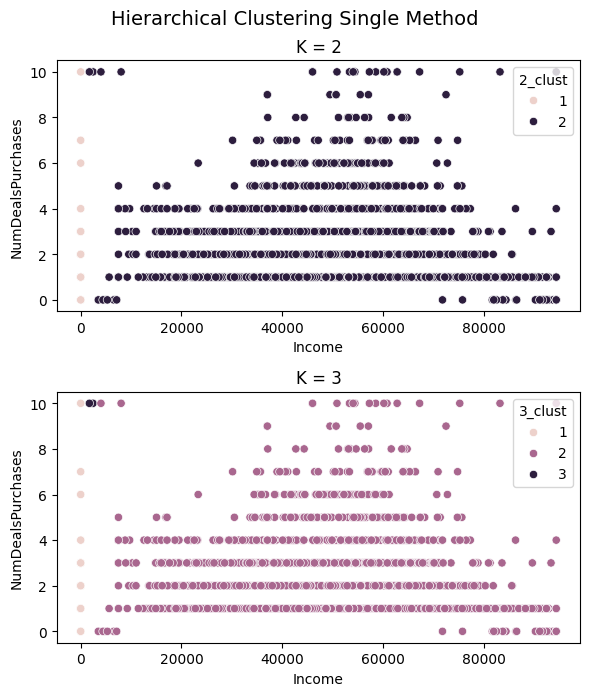

In [46]:
plt.figure(figsize=(6,10))

plt.suptitle('Hierarchical Clustering Single Method',fontsize=14)

plt.subplot(3,1,1)
plt.title('K = 2',fontsize=12)
sns.scatterplot(x='Income',y='NumDealsPurchases', data=X_clipped, hue='2_clust')

plt.subplot(3,1,2)
plt.title('K = 3',fontsize=12)
sns.scatterplot(x='Income',y='NumDealsPurchases', data=X_clipped, hue='3_clust')

plt.tight_layout();

In [47]:
col_names = X_clipped.columns.tolist()

<Axes: ylabel='2_clust'>

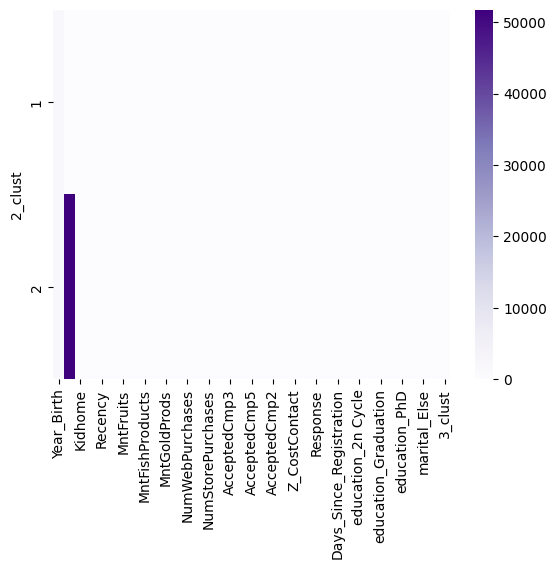

In [48]:
sns.heatmap(X_clipped[col_names].groupby('2_clust').mean(), cmap='Purples')

<Axes: ylabel='3_clust'>

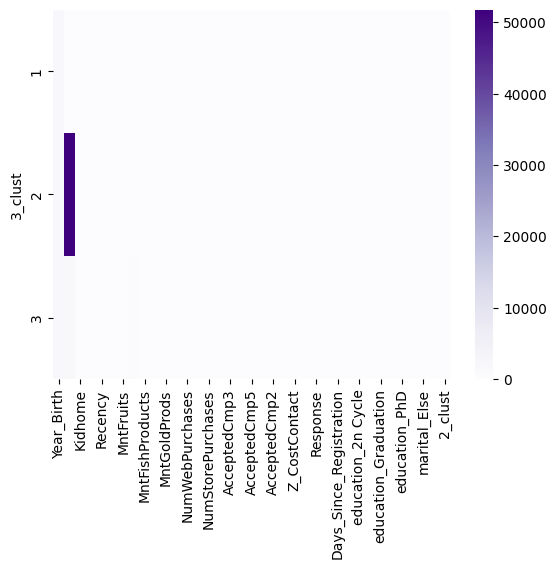

In [49]:
sns.heatmap(X_clipped[col_names].groupby('3_clust').mean(), cmap='Purples')

Виглядає, наче розділення на кластери відбувалося лише за критерієм річного доходу (`Income`) за методом ієрархічної агломеративної кластеризації. Вважаю це недоречним і неякісним, тому скоріше за все метрика силуету теж буде низькою.

In [50]:
s_2 = silhouette_score(X_clipped, X_clipped['2_clust'], metric='euclidean')
s_3 = silhouette_score(X_clipped, X_clipped['3_clust'], metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters by AHC:\nfor 2 clusters = {s_2:.2f}\nfor 3 clusters = {s_3:.2f}')

Silhouette Coefficient for the data Dataset Clusters by AHC:
for 2 clusters = 0.45
for 3 clusters = 0.43


Кластеризація за KMean на невідмасштабованих даних з видаленими викидами показала себе краще ніж агломеративна ієрархічна кластеризація

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте метрику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

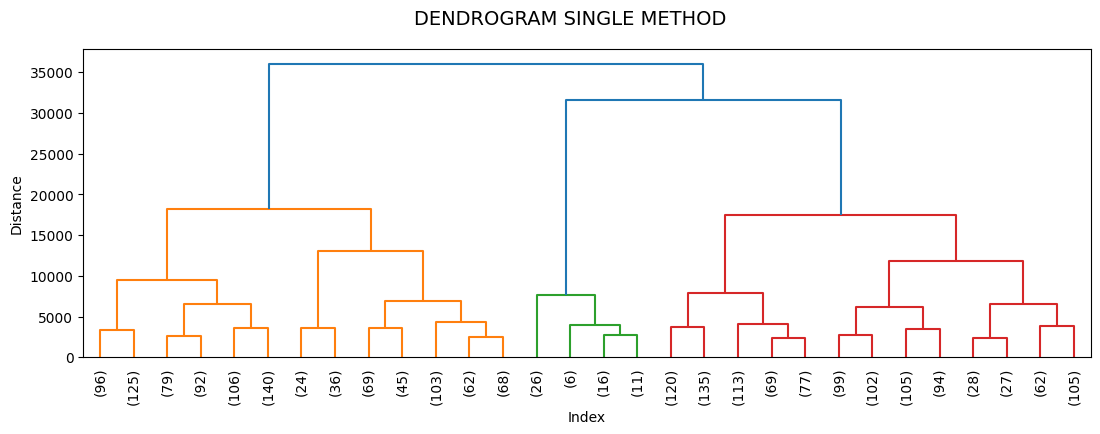

In [51]:
dist_sin_avg = linkage(X_clipped, method='average')

plt.figure(figsize=(13,4))
dendrogram(dist_sin_avg, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle('DENDROGRAM SINGLE METHOD', fontsize=14)
plt.show()

In [60]:
X_clipped['2_clust_avg'] = fcluster(dist_sin_avg, 2, criterion='maxclust')

In [61]:
s_avg = silhouette_score(X_clipped, X_clipped['2_clust_avg'], metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s_avg:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.60


In [54]:
from sklearn.cluster import MeanShift, estimate_bandwidth

In [55]:
bandwidth = estimate_bandwidth(
    X_scaled_df, quantile=0.2, n_samples=500, random_state=42
)

In [56]:
meanshift = MeanShift(bandwidth=bandwidth, bin_seeding=True, cluster_all=False)
meanshift.fit_predict(X_scaled_df)
labels = meanshift.labels_
print(labels)

[-1  0  0 ...  0  0  0]


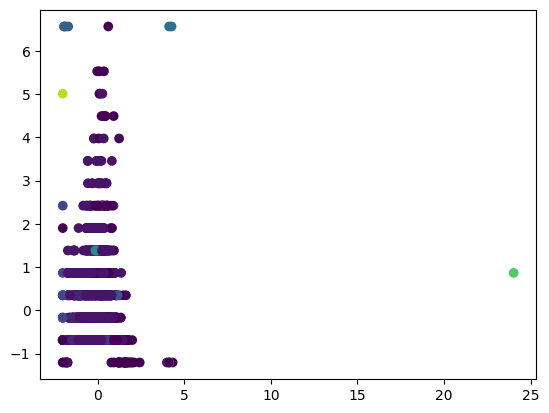

In [57]:
plt.scatter(X_scaled_df['Income'], X_scaled_df['NumDealsPurchases'], c=labels)
plt.show()

In [62]:
s = silhouette_score(X_scaled_df, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.22


Поки що AHC+avarage linkage на даних з обрізаними викидами показав такий самий результат за метрикою силуету як і KMeans на зовсім необроблених даних (`0.57`). А MeanShift на заскейлених даних із StandartScaler та з викидами (які інтепритувались як шум) показав нижчий результат метрики (= `0.22`)

З методів, на яких робилися експеременти, я б обрала скоріше для застосування на практиці саме KMeans на необроблених даних, оскільки він є найпростішим у реалізації але показує ефективність, яка не поступається складнішим моделям.